In [1]:
import tensorflow as tf
import numpy as np
import time
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, ReLU, Flatten
from keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.initializers import  RandomNormal
from keras.callbacks import ModelCheckpoint, TensorBoard
#from keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU
from tensorflow.keras.layers import MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense, Add


In [ ]:
TRAIN_DIR= os.path.join("../affectnet_dataset/Train")
TEST_DIR = os.path.join("../affectnet_dataset/Test")
RANDOM_SEED = 40
BATCH_SIZE = 64
EPOCHS = 100
IMAGE_WIDTH = 96
IMAGE_HEIGHT = 96
SAVED_MODEL='../saved_models/cnn_kaggle_model.h5'

In [3]:
# Train/Validation(80/20)
# Normalization of px for stable training (rescale)
# train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
#     rescale=1./255,
#     validation_split=0.2,

#     # Augmentation
#     rotation_range=10,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.1,
#     shear_range=0.1,
#     brightness_range=[0.8, 1.2],
#     horizontal_flip=True,

#     fill_mode='nearest'
# )

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    # Rotation / shift / scale / shear
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.15,

    # Brightness, contrast, horizontal flip, fill-mode
    brightness_range=[0.6, 1.4],
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)


In [4]:
# LOADING TRAIN/VAL/TEST DATA
print("Loading Training Data...")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=BATCH_SIZE,
    target_size=(96, 96),
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

print("Loading Validation Data...")
validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    batch_size=BATCH_SIZE,
    target_size=(96, 96),
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

print("Loading Test Data...")
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    batch_size=BATCH_SIZE,
    target_size=(96, 96),
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False
)

# Auto detect labels
CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = train_generator.num_classes
print(f"Detected {NUM_CLASSES} classes: {CLASS_NAMES}")

Loading Training Data...
Found 12890 images belonging to 8 classes.
Loading Validation Data...
Found 3218 images belonging to 8 classes.
Loading Test Data...
Found 14518 images belonging to 8 classes.
Detected 8 classes: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [5]:
def residual_block(x, filters):
    shortcut = x

    x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)

    x = Add()([shortcut, x])
    x = ReLU()(x)
    return x


inputs = Input(shape=(96,96,3))
# Block 1
x = Conv2D(64, 3, padding='same', kernel_initializer='he_normal')(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)
x = residual_block(x, 64)
x = MaxPooling2D(2)(x)
x = Dropout(0.2)(x)
# Block 2
x = Conv2D(128, 3, padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = residual_block(x, 128)
x = MaxPooling2D(2)(x)
x = Dropout(0.3)(x)
# Block 3
x = Conv2D(256, 3, padding='same', kernel_initializer='he_normal')(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = residual_block(x, 256)
x = MaxPooling2D(2)(x)
x = Dropout(0.3)(x)
# GAP + Dense
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(8, activation='softmax')(x)
model = Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 96,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 96, 96,    │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 96, 96,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 96, 96,    │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 96, 96,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96,    │          0 │ re_lu[0][0],      │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 96, 96,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ re_lu_2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48, 48,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 48,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │    147,584 │ re_lu_3[0][0]   

 Total params: 1,993,224 (7.60 MB)

 Trainable params: 1,990,536 (7.59 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [6]:
model.compile(loss='categorical_crossentropy', optimizer=AdamW(), metrics=['accuracy'])

In [7]:
# CALLBACKS
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=SAVED_MODEL,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_accuracy', save_best_only=True)
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5
)


In [8]:
# TRAINING
start = time.time()
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[es, mc, rlr,checkpoint]

)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))


Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1758 - loss: 2.2736


Epoch 1: val_loss improved from None to 2.02283, saving model to ../saved_models/cnn_kaggle_model.h5



Epoch 1: finished saving model to ../saved_models/cnn_kaggle_model.h5
202/202 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.1915 - loss: 2.1010 - val_accuracy: 0.2119 - val_loss: 2.0228 - learning_rate: 0.0010
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2239 - loss: 1.9961


Epoch 2: val_loss improved from 2.02283 to 1.94174, saving model to ../saved_models/cnn_kaggle_model.h5



Epoch 2: finished saving model to ../saved_models/cnn_kaggle_model.h5
202/202 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.2332 - loss: 1.9747 - val_accuracy: 0.2452 - val_loss: 1.9417 - learning_rate: 0.0010
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2775 - loss: 1.8267

...


Epoch 80: finished saving model to ../saved_models/cnn_kaggle_model.h5
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6886 - loss: 0.8400 - val_accuracy: 0.6625 - val_loss: 0.8851 - learning_rate: 2.4300e-06
Epoch 81/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6797 - loss: 0.8622
Epoch 81: val_loss did not improve from 0.88512
202/202 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.6860 - loss: 0.8518 - val_accuracy: 0.6554 - val_loss: 0.8902 - learning_rate: 2.4300e-06
Epoch 82/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6867 - loss: 0.8485
Epoch 82: val_loss improved from 0.88512 to 0.88247, saving model to ../saved_models/cnn_kaggle_model.h5



Epoch 82: finished saving model to ../saved_models/cnn_kaggle_model.h5
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6893 - loss: 0.8430 - val_accuracy: 0.6616 - val_loss: 0.8825 - learning_rate: 2.4300e-06
Epoch 83/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6876 - loss: 0.8514
Epoch 83: val_loss did not improve from 0.88247
202/202 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.6859 - loss: 0.8520 - val_accuracy: 0.6594 - val_loss: 0.8826 - learning_rate: 2.4300e-06
Epoch 84/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6809 - loss: 0.8600
Epoch 84: val_loss improved from 0.88247 to 0.88049, saving model to ../saved_models/cnn_kaggle_model.h5



Epoch 84: finished saving model to ../saved_models/cnn_kaggle_model.h5
202/202 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.6845 - loss: 0.8521 - val_accuracy: 0.6566 - val_loss: 0.8805 - learning_rate: 2.4300e-06
Epoch 85/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6887 - loss: 0.8469
Epoch 85: val_loss did not improve from 0.88049
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6884 - loss: 0.8448 - val_accuracy: 0.6591 - val_loss: 0.8824 - learning_rate: 2.4300e-06
Epoch 86/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6862 - loss: 0.8525
Epoch 86: val_loss did not improve from 0.88049
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6888 - loss: 0.8462 - val_accuracy: 0.6613 - val_loss: 0.8899 - learning_rate: 2.4300e-06
Epoch 87/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6875 - loss: 0.8481


Epoch 87: val_loss did not improve from 0.88049
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6854 - loss: 0.8478 - val_accuracy: 0.6650 - val_loss: 0.8821 - learning_rate: 2.4300e-06
Epoch 88/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6922 - loss: 0.8421
Epoch 88: val_loss did not improve from 0.88049
202/202 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.6895 - loss: 0.8507 - val_accuracy: 0.6566 - val_loss: 0.8948 - learning_rate: 2.4300e-06
Epoch 89/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6855 - loss: 0.8546
Epoch 89: val_loss did not improve from 0.88049
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6827 - loss: 0.8553 - val_accuracy: 0.6551 - val_loss: 0.8877 - learning_rate: 2.4300e-06
Epoch 90/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6942 - loss: 0.8497
Epoch 90: val_loss did not improve from 0.88049
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6899 - loss: 0.8488 - val_accuracy: 0.6631 - val_los


Epoch 91: finished saving model to ../saved_models/cnn_kaggle_model.h5
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6883 - loss: 0.8441 - val_accuracy: 0.6597 - val_loss: 0.8757 - learning_rate: 7.2900e-07
Epoch 92/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6849 - loss: 0.8572
Epoch 92: val_loss did not improve from 0.87573
202/202 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.6888 - loss: 0.8415 - val_accuracy: 0.6482 - val_loss: 0.8962 - learning_rate: 7.2900e-07
Epoch 93/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6881 - loss: 0.8420
Epoch 93: val_loss did not improve from 0.87573
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6878 - loss: 0.8474 - val_accuracy: 0.6551 - val_loss: 0.9023 - learning_rate: 7.2900e-07
Epoch 94/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6894 - loss: 0.8441
Epoch 94: val_loss did not improve from 0.87573
202/202 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.6872 - loss: 0.8488 - val_acc

In [9]:
with open("../saved_models/train_history.pkl", "wb") as f:
    pickle.dump(history.history, f)
print("Saved training history to train_history.pkl")

Saved training history to train_history.pkl


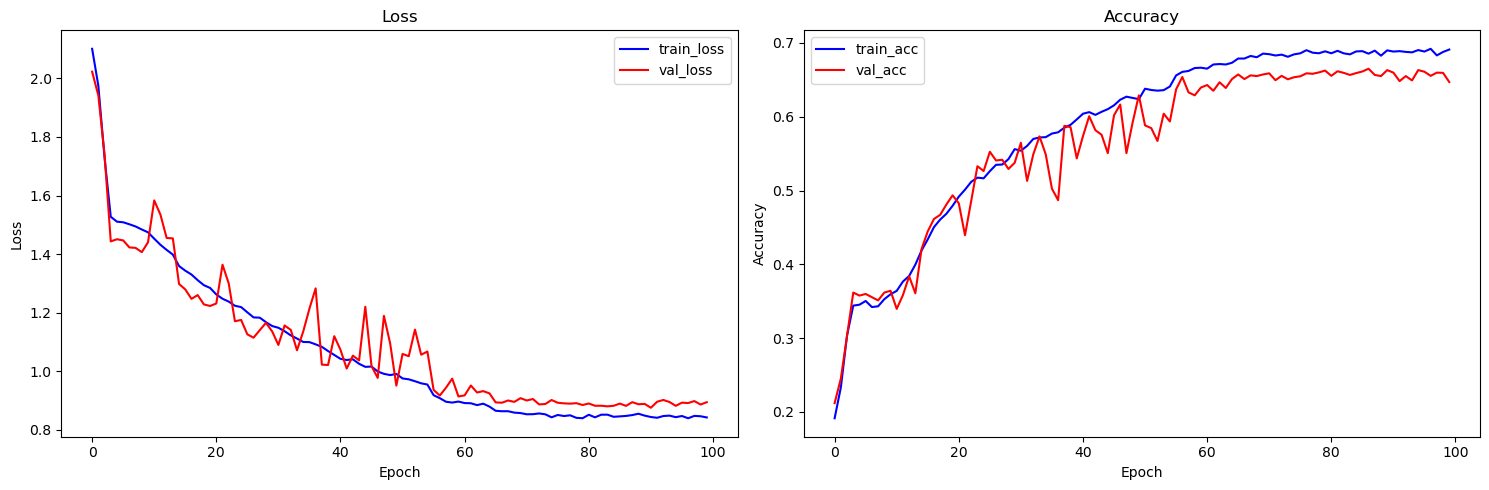

In [10]:
def visualize_train_history(history):
    plt.figure(figsize=(15,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history['loss'], label='train_loss', color='blue')
    plt.plot(history['val_loss'], label='val_loss', color='red')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history['accuracy'], label='train_acc', color='blue')
    plt.plot(history['val_accuracy'], label='val_acc', color='red')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()



with open("../saved_models/train_history.pkl", "rb") as f:
    saved_history = pickle.load(f)

visualize_train_history(saved_history)

In [11]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

227/227 ━━━━━━━━━━━━━━━━━━━━ 81s 357ms/step - accuracy: 0.6162 - loss: 1.9185
Test Accuracy: 61.62%


In [12]:
# LOAD BEST MODEL
model.load_weights(SAVED_MODEL)
print("Loaded best model with lowest validation loss.")

Loaded best model with lowest validation loss.


In [13]:
print(list(train_generator.class_indices))
print(list(test_generator.class_indices))

['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


Evaluating on Test Set...
227/227 ━━━━━━━━━━━━━━━━━━━━ 81s 357ms/step - accuracy: 0.6162 - loss: 1.9185
Test Accuracy: 61.62%
Generating predictions...
227/227 ━━━━━━━━━━━━━━━━━━━━ 81s 357ms/step

Classification Report:

              precision    recall  f1-score   support

       anger       0.58      0.37      0.45      1718
    contempt       0.54      0.67      0.60      1312
     disgust       0.58      0.23      0.33      1248
        fear       0.67      0.22      0.33      1664
       happy       0.90      0.91      0.91      2704
     neutral       0.72      0.93      0.81      2368
         sad       0.43      0.74      0.54      1584
    surprise       0.42      0.50      0.46      1920

    accuracy                           0.62     14518
   macro avg       0.61      0.57      0.55     14518
weighted avg       0.63      0.62      0.59     14518



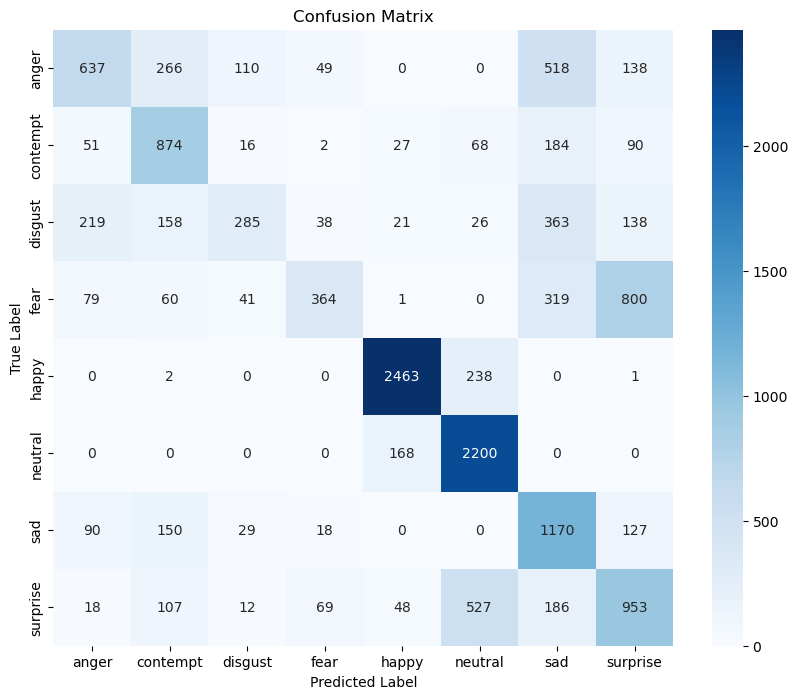

In [14]:
# EVALUATE ON TEST SET
def report_test_results():
    print("Evaluating on Test Set...")

    loss, accuracy = model.evaluate(test_generator)
    print(f"Test Accuracy: {accuracy*100:.2f}%")
    print("Generating predictions...")
    predictions = model.predict(test_generator, verbose=1)
    
    # Convert predictions to class indexes
    y_pred_indices = np.argmax(predictions, axis=1)
    
    # Get true labels directly from the generator
    y_true_indices = test_generator.classes
    
    # Get the class names (labels)
    class_labels = list(test_generator.class_indices.keys())

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_true_indices, y_pred_indices, target_names=class_labels))

    # Confusion Matrix
    cm = confusion_matrix(y_true_indices, y_pred_indices)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

report_test_results()

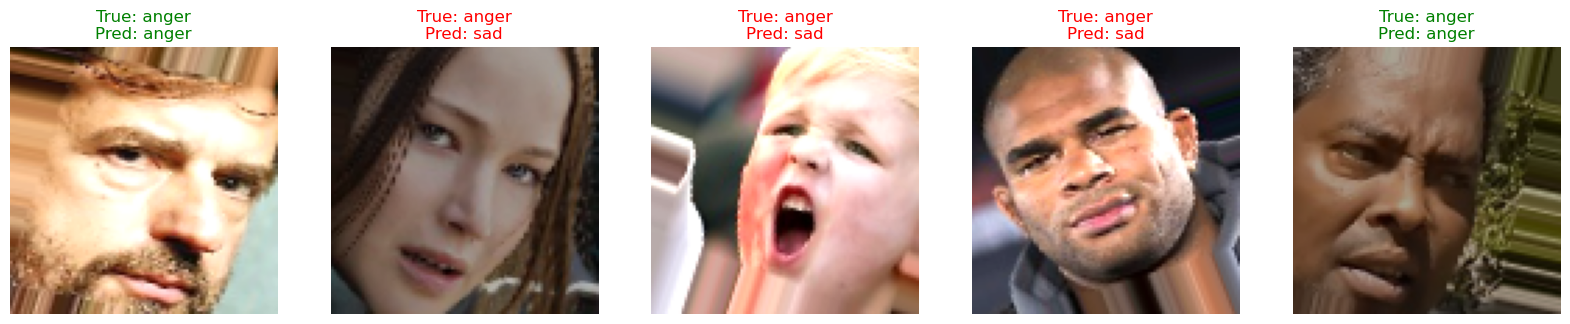

In [15]:
def predict_random_samples():
    # Grab a single batch of images
    # We use next() to fetch the first batch from the generator
    images, labels = next(validation_generator)
    
    # Pick 5 random indices from this batch (batch size is usually 32)
    indices = np.random.choice(len(images), 5, replace=False)
    
    # Get class names map {0: 'angry', 1: 'happy', ...}
    class_map = {v: k for k, v in validation_generator.class_indices.items()}
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for i, idx in enumerate(indices):
        img = images[idx]
        
        # Get True Label
        true_idx = np.argmax(labels[idx])
        true_label = class_map[true_idx]
        
        # Get Prediction
        # Add extra dim because model expects (Batch, Height, Width, Channel)
        pred_prob = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_idx = np.argmax(pred_prob)
        pred_label = class_map[pred_idx]
        
        # Display Image
        # Squeeze removes the channel dim (48,48,1) -> (48,48) for plotting
        axes[i].imshow(img.squeeze(), cmap='gray')
        axes[i].axis('off')
        
        # Title color: Green if correct, Red if wrong
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color)
        
    plt.show()

predict_random_samples()